In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
PREDSDIR   = CONFIGS['filepaths']['predictions']
FIELDVARS  = CONFIGS['experiments']['nn']['runs']['nn_gauss']['fieldvars']
SEEDS      = CONFIGS['experiments']['nn']['seeds']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
SPLIT      = 'test'
NBINS      = 20
MINSAMPLES = 50
MINPRECIP  = 0.1
LFCLASSES  = {'Ocean':((0.0,0.1),'#539ED4'),'Coast':((0.1,0.9),'gray6'),'Land':((0.9,1.01),'#A0522D')}
REGISTRY   = {row['name']:dict(form=row['form'],constants=json.loads(row['constants']),train_loss=row['train_loss'],valid_loss=row['valid_loss'])
              for _,row in pd.read_csv(os.path.join(MODELSDIR,'sr','optimized_equations.csv')).iterrows()}

In [4]:
def kernel_integrate(fields,weights,dsig):
    return (fields*weights[None,:,:]*dsig[None,None,:]).sum(axis=2)

def calc_dominant_term(rh,thetae,thetaestar):
    return np.maximum(kappa*(rh-rh0),thetae-gamma*thetaestar-thetac)

def calc_sensible_term(lf,shf):
    return lamshf*(lfc-lf)*(shf-shf0)

def calc_latent_term(lhf):
    return lamlhf*(lhf-lhf0)

def to_precip(exponent):
    return np.maximum(np.expm1(exponent),0.0)

def bin_1d(x,z,edges,minsamples=MINSAMPLES):
    xi     = np.clip(np.digitize(x,edges)-1,0,len(edges)-2)
    counts = np.bincount(xi,minlength=len(edges)-1)
    sums   = np.bincount(xi,weights=z,minlength=len(edges)-1)
    return 0.5*(edges[:-1]+edges[1:]),np.where(counts>=minsamples,sums/np.maximum(counts,1),np.nan)

def calc_slope(x,y,minsamples=MINSAMPLES):
    if x.size<minsamples:
        return np.nan
    xanom = x-x.mean()
    return np.dot(xanom,y-y.mean())/np.dot(xanom,xanom)

def bin_2d(x,y,z,edges,minsamples=MINSAMPLES):
    xi     = np.clip(np.digitize(x,edges[0])-1,0,len(edges[0])-2)
    yi     = np.clip(np.digitize(y,edges[1])-1,0,len(edges[1])-2)
    shape  = (len(edges[0])-1,len(edges[1])-1)
    counts = np.zeros(shape)
    sums   = np.zeros(shape)
    np.add.at(counts,(xi,yi),1)
    np.add.at(sums,(xi,yi),z)
    return np.where(counts>=minsamples,sums/np.maximum(counts,1),np.nan)

In [5]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
c3,c4,c5 = (REGISTRY['sr_atm_eq']['constants'][name] for name in ['c3','c4','c5'])
c6,c7,c8 = (REGISTRY['sr_sfc_eq']['constants'][name] for name in ['c6','c7','c8'])

eta    = STATS['tp_std']*c3/STATS['thetae_std']**3
gamma  = c4*STATS['thetae_std']/STATS['thetaestar_std']
thetac = STATS['thetae_mean']-gamma*STATS['thetaestar_mean']+c5*STATS['thetae_std']
kappa  = STATS['thetae_std']/STATS['rh_std']
rh0    = STATS['rh_mean']

lamshf = STATS['tp_std']*c6/STATS['shf_std']
lfc    = c7
shf0   = STATS['shf_mean']
lamlhf = STATS['tp_std']*c8/STATS['lhf_std']
lhf0   = STATS['lhf_mean']

constdf = pd.DataFrame([
    {'Constant':'$\\lambda_\mathrm{S}$','Value':f'{lamshf:.3e}','Units':'m²/W'},
    {'Constant':'$\\mathrm{LF}_c$','Value':f'{lfc:.2f}','Units':'dimensionless'},
    {'Constant':'$\\mathrm{SHF}_0$','Value':f'{shf0:.2f}','Units':'W/m²'},
    {'Constant':'$\\lambda_\mathrm{L}$','Value':f'{lamlhf:.3e}','Units':'m²/W'},
    {'Constant':'$\\mathrm{LHF}_0$','Value':f'{lhf0:.2f}','Units':'W/m²'}])
display(constdf.style.hide(axis='index'))

Constant,Value,Units
$\lambda_\mathrm{S}$,1.250e-02,m²/W
$\mathrm{LF}_c$,0.74,dimensionless
$\mathrm{SHF}_0$,13.91,W/m²
$\lambda_\mathrm{L}$,1.564e-03,m²/W
$\mathrm{LHF}_0$,124.39,W/m²


In [6]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    ntime,nlat,nlon = (ds.sizes[dim] for dim in ['time','lat','lon'])
    lat,lon,dsig    = ds['lat'].values,ds['lon'].values,ds['dsig'].values
    fields = np.stack([ds[name].transpose('time','lat','lon','sig').values.reshape(-1,dsig.size) for name in FIELDVARS],axis=1)
    tp,shf,lhf = (ds[name].transpose('time','lat','lon').values.ravel() for name in ['tp','shf','lhf'])
    lf     = xr.broadcast(ds['lf'],ds['tp'])[0].transpose('time','lat','lon').values.ravel()
with xr.open_dataset(os.path.join(PREDSDIR,f'sr_sfc_eq_{SPLIT}_predictions.nc')) as ds:
    savedtp = ds['tp'].squeeze().transpose('time','lat','lon').values.ravel()

kernels = []
for seed in SEEDS:
    with xr.open_dataset(os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc'),engine='h5netcdf') as ds:
        kernels.append(ds['k'].values)
integrals    = dict(zip(FIELDVARS,kernel_integrate(fields,np.mean(kernels,axis=0),dsig).T))
dominant     = calc_dominant_term(integrals['rh'],integrals['thetae'],integrals['thetaestar'])
sensibleterm = calc_sensible_term(lf,shf)
latentterm   = calc_latent_term(lhf)
surfaceterm  = sensibleterm+latentterm
atmtp        = to_precip(eta*dominant**3)
sfctp        = to_precip(eta*dominant**3+surfaceterm)
finite       = np.isfinite(dominant)&np.isfinite(surfaceterm)&np.isfinite(tp)
favorable    = finite&(atmtp>=MINPRECIP)
missed       = tp-atmtp
added        = sfctp-atmtp
print(f'Max difference from saved SR-SFC predictions: {np.nanmax(np.abs(sfctp[finite]-savedtp[finite])):.2e} mm')

lfmasks = {name:(lf>=bounds[0])&(lf<bounds[1]) for name,(bounds,_) in LFCLASSES.items()}
colors  = {name:color for name,(_,color) in LFCLASSES.items()}

Max difference from saved SR-SFC predictions: 8.94e-02 mm


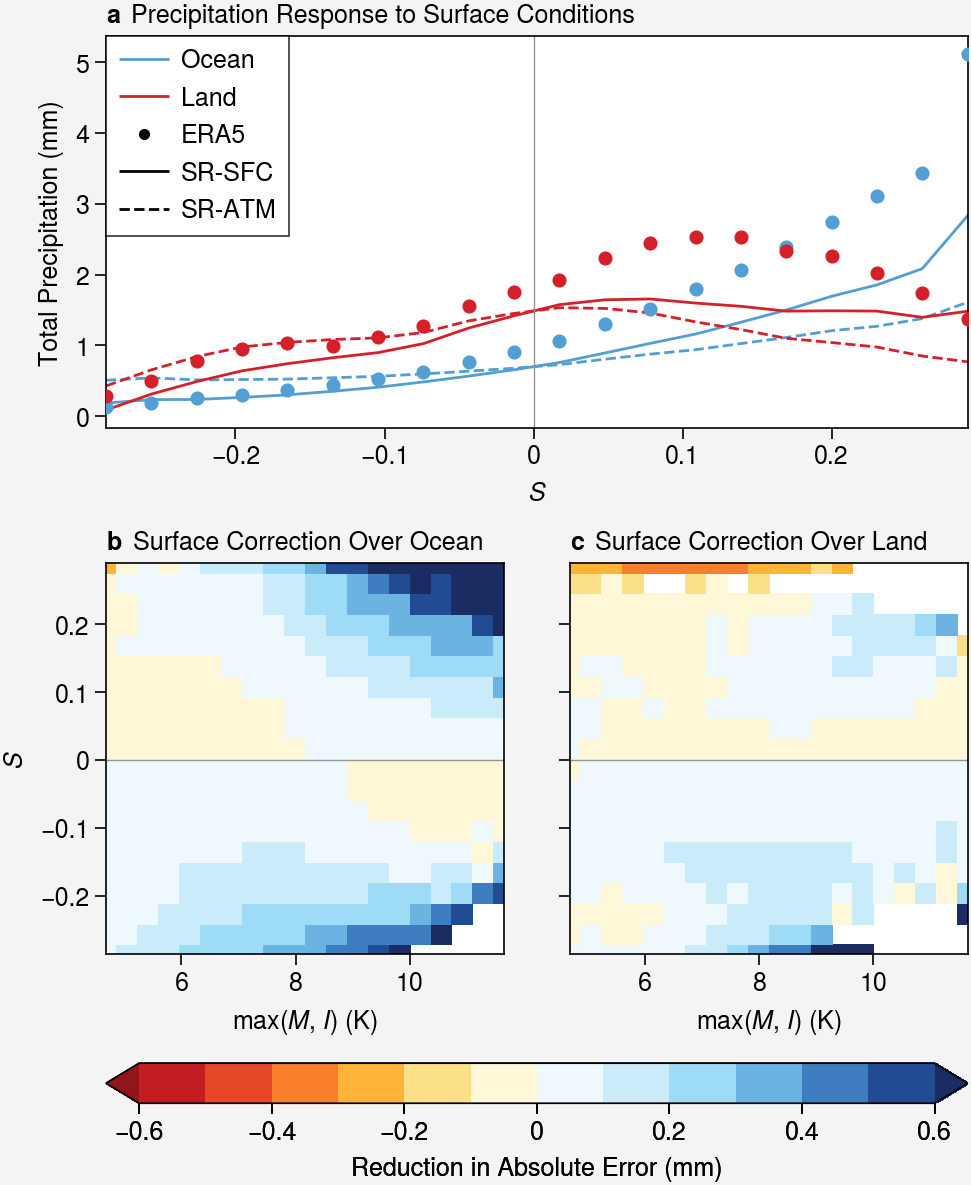

In [7]:
regions   = {'Ocean':(favorable&(lf<0.5),'#539ED4'),'Land':(favorable&(lf>=0.5),'#D42028')}
reduction = np.abs(tp-atmtp)-np.abs(tp-sfctp)
medges = np.linspace(*np.percentile(dominant[favorable],[1,99]),NBINS+1)
sedges = np.linspace(*np.percentile(surfaceterm[favorable],[1,99]),NBINS+1)
binedges   = (medges,sedges)
bincenters = [0.5*(edge[:-1]+edge[1:]) for edge in binedges]
improved   = {}
for region,(mask,_) in regions.items():
    improved[region] = bin_2d(dominant[mask],surfaceterm[mask],reduction[mask],binedges)
redlim = np.nanpercentile(np.abs(list(improved.values())),98)

fig,axs = pplt.subplots(array=[[1,1],[2,3]],figwidth=5,figheight=6,share=False,span=False)
axs.format(abc=True,titleloc='l',grid=False)
for region,(mask,color) in regions.items():
    centers,era5mean = bin_1d(surfaceterm[mask],tp[mask],sedges)
    _,sfcmean = bin_1d(surfaceterm[mask],sfctp[mask],sedges)
    _,atmmean = bin_1d(surfaceterm[mask],atmtp[mask],sedges)
    axs[0].scatter(centers,era5mean,color=color,markersize=20,zorder=3)
    axs[0].plot(centers,sfcmean,color=color,linewidth=1,label=region)
    axs[0].plot(centers,atmmean,color=color,linestyle='--',linewidth=1)

for label,kwargs in [('ERA5',dict(marker='o',linestyle='none',markersize=3)),('SR-SFC',dict(linewidth=1)),('SR-ATM',dict(linestyle='--',linewidth=1))]:
    axs[0].plot([],[],color='black',label=label,**kwargs)
axs[0].axvline(0,color='gray',linewidth=0.5)
axs[0].format(title='Precipitation Response to Surface Conditions',xlabel='$\\mathit{S}$',ylabel='Total Precipitation (mm)')
axs[0].legend(loc='ul',ncols=1)

for ax,(region,values) in zip(axs[1:],improved.items()):
    m = ax.pcolormesh(*bincenters,values.T,cmap='ColdHot_r',vmin=-redlim,vmax=redlim,levels=16,extend='both')
    ax.axhline(0,color='gray',linewidth=0.5)
    ax.format(title=f'Surface Correction Over {region}')

axs[1:].format(xlabel='max($\\mathit{M}$, $\\mathit{I}$) (K)',xlim=(bincenters[0][0],bincenters[0][-1]),
               ylim=(bincenters[1][0],bincenters[1][-1]))
axs[1].format(ylabel='$\\mathit{S}$')
axs[2].format(yticklabels=[])
fig.colorbar(m,loc='b',cols=(1,2),label='Reduction in Absolute Error (mm)',ticks=0.2)
pplt.show()
fig.save('../figs/fig_5.jpg')